In [1]:
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("OpenCV:", cv2.__version__)

PyTorch: 2.14.1+cpu
OpenCV: 5.0.0


In [2]:
class RetailCNN(nn.Module):

    def __init__(self, num_classes=6):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [3]:
device = torch.device("cpu")

class_names = [
    "aqua",
    "chitato",
    "indomie",
    "pepsodent",
    "shampoo",
    "tissue"
]

model = RetailCNN(num_classes=6)
model = model.to(device)

model.load_state_dict(
    torch.load(
        "../models/retail_cnn_pytorch_best.pth",
        map_location=device
    )
)

model.eval()

print("PyTorch model loaded successfully!")
print("Device:", device)
print("Classes:", class_names)

PyTorch model loaded successfully!
Device: cpu
Classes: ['aqua', 'chitato', 'indomie', 'pepsodent', 'shampoo', 'tissue']


In [4]:
test_image_path = "../data/processed/classification_preprocessed/test/aqua/aqua (1)_object_1.jpg"

print("Image path:", test_image_path)

Image path: ../data/processed/classification_preprocessed/test/aqua/aqua (1)_object_1.jpg


In [5]:
image = cv2.imread(test_image_path)

if image is None:
    print("Image could not be loaded.")
else:
    print("Image loaded successfully!")
    print("Shape:", image.shape)
    print("Data type:", image.dtype)

Image loaded successfully!
Shape: (224, 224, 3)
Data type: uint8


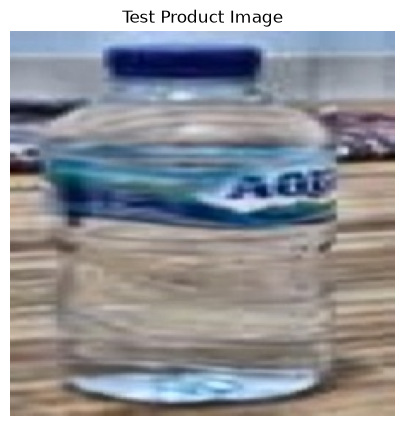

In [6]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Test Product Image")
plt.show()

In [7]:
# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize to the CNN input size
image_resized = cv2.resize(image_rgb, (224, 224))

# Apply Gaussian blur
image_blurred = cv2.GaussianBlur(
    image_resized,
    (3, 3),
    0
)

# Convert RGB to LAB
image_lab = cv2.cvtColor(
    image_blurred,
    cv2.COLOR_RGB2LAB
)

# Split LAB channels
l_channel, a_channel, b_channel = cv2.split(image_lab)

# Apply CLAHE to the L channel
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

l_enhanced = clahe.apply(l_channel)

# Merge channels
image_lab_enhanced = cv2.merge(
    [l_enhanced, a_channel, b_channel]
)

# Convert LAB back to RGB
image_preprocessed = cv2.cvtColor(
    image_lab_enhanced,
    cv2.COLOR_LAB2RGB
)

print("Preprocessing completed!")
print("Final shape:", image_preprocessed.shape)
print("Final dtype:", image_preprocessed.dtype)

Preprocessing completed!
Final shape: (224, 224, 3)
Final dtype: uint8


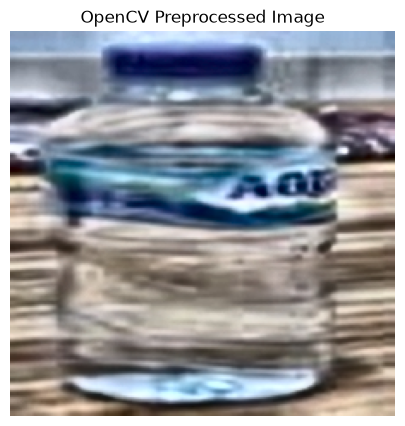

In [8]:
plt.figure(figsize=(5, 5))

plt.imshow(image_preprocessed)
plt.axis("off")
plt.title("OpenCV Preprocessed Image")

plt.show()

In [9]:
# Convert image values from 0-255 to 0-1
image_array = image_preprocessed.astype(np.float32) / 255.0

# Convert NumPy array to PyTorch tensor
image_tensor = torch.from_numpy(image_array)

# Change shape from (224, 224, 3) to (3, 224, 224)
image_tensor = image_tensor.permute(2, 0, 1)

# Add batch dimension
image_tensor = image_tensor.unsqueeze(0)

# Move tensor to CPU
image_tensor = image_tensor.to(device)

print("Tensor shape:", image_tensor.shape)
print("Tensor dtype:", image_tensor.dtype)
print("Minimum value:", image_tensor.min().item())
print("Maximum value:", image_tensor.max().item())

Tensor shape: torch.Size([1, 3, 224, 224])
Tensor dtype: torch.float32
Minimum value: 0.0
Maximum value: 1.0


In [10]:
with torch.no_grad():
    outputs = model(image_tensor)

print("Model output shape:", outputs.shape)
print("Model outputs:", outputs)

Model output shape: torch.Size([1, 6])
Model outputs: tensor([[ 10.5547,  -8.5807,  -5.9278,  -6.1739,   3.3704, -17.2882]])


In [11]:
# Convert logits to probabilities
probabilities = torch.softmax(outputs, dim=1)

# Get the highest probability
confidence, predicted_index = torch.max(probabilities, dim=1)

# Get the predicted class name
predicted_class = class_names[predicted_index.item()]

print("Predicted product:", predicted_class)
print("Confidence:", confidence.item() * 100, "%")

Predicted product: aqua
Confidence: 99.92421865463257 %


In [12]:
for class_name, probability in zip(
    class_names,
    probabilities[0]
):
    print(
        f"{class_name:10s}: {probability.item() * 100:.2f}%"
    )

aqua      : 99.92%
chitato   : 0.00%
indomie   : 0.00%
pepsodent : 0.00%
shampoo   : 0.08%
tissue    : 0.00%


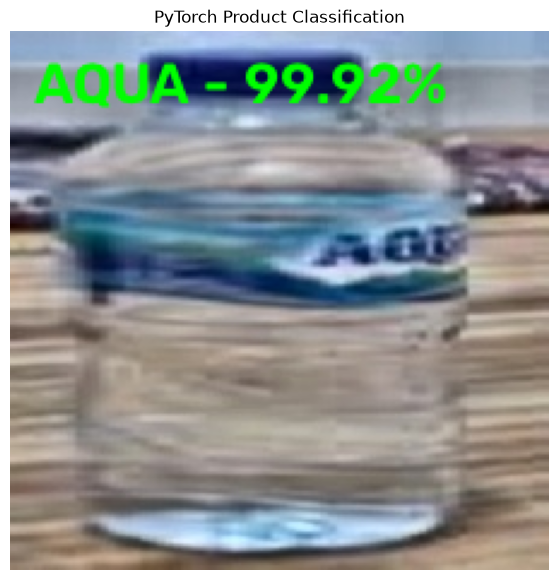

In [13]:
# Create a copy of the original image
result_image = image_rgb.copy()

# Create prediction text
prediction_text = f"{predicted_class.upper()} - {confidence.item() * 100:.2f}%"

# Add text to the image
cv2.putText(
    result_image,
    prediction_text,
    (10, 30),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (0, 255, 0),
    2,
    cv2.LINE_AA
)

# Display result
plt.figure(figsize=(7, 7))
plt.imshow(result_image)
plt.axis("off")
plt.title("PyTorch Product Classification")
plt.show()

In [14]:
test_images = {
    "aqua": "../data/processed/classification_preprocessed/test/aqua/aqua (1)_object_1.jpg",
    "chitato": "../data/processed/classification_preprocessed/test/chitato/chitato (1)_object_1.jpg",
    "indomie": "../data/processed/classification_preprocessed/test/indomie/indomie (1)_object_1.jpg",
    "pepsodent": "../data/processed/classification_preprocessed/test/pepsodent/pepsodent (1)_object_1.jpg",
    "shampoo": "../data/processed/classification_preprocessed/test/shampoo/shampoo (1)_object_1.jpg",
    "tissue": "../data/processed/classification_preprocessed/test/tissue/tissue (1)_object_1.jpg"
}

print("Number of test images:", len(test_images))

for product, path in test_images.items():
    print(product, "→", path)

Number of test images: 6
aqua → ../data/processed/classification_preprocessed/test/aqua/aqua (1)_object_1.jpg
chitato → ../data/processed/classification_preprocessed/test/chitato/chitato (1)_object_1.jpg
indomie → ../data/processed/classification_preprocessed/test/indomie/indomie (1)_object_1.jpg
pepsodent → ../data/processed/classification_preprocessed/test/pepsodent/pepsodent (1)_object_1.jpg
shampoo → ../data/processed/classification_preprocessed/test/shampoo/shampoo (1)_object_1.jpg
tissue → ../data/processed/classification_preprocessed/test/tissue/tissue (1)_object_1.jpg


In [15]:
for product, path in test_images.items():

    test_image = cv2.imread(path)

    if test_image is None:
        print(f"❌ {product}: Image could not be loaded")
    else:
        print(f"✅ {product}: Loaded successfully - {test_image.shape}")

✅ aqua: Loaded successfully - (224, 224, 3)
✅ chitato: Loaded successfully - (224, 224, 3)
✅ indomie: Loaded successfully - (224, 224, 3)
✅ pepsodent: Loaded successfully - (224, 224, 3)
✅ shampoo: Loaded successfully - (224, 224, 3)
✅ tissue: Loaded successfully - (224, 224, 3)


In [16]:
results = []

for actual_product, path in test_images.items():

    # Load image
    test_image = cv2.imread(path)

    # Convert BGR → RGB
    test_image_rgb = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)

    # Resize
    test_image_resized = cv2.resize(
        test_image_rgb,
        (224, 224)
    )

    # Gaussian blur
    test_image_blurred = cv2.GaussianBlur(
        test_image_resized,
        (3, 3),
        0
    )

    # RGB → LAB
    test_image_lab = cv2.cvtColor(
        test_image_blurred,
        cv2.COLOR_RGB2LAB
    )

    # CLAHE
    l_channel, a_channel, b_channel = cv2.split(test_image_lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l_enhanced = clahe.apply(l_channel)

    # Merge LAB channels
    test_image_lab_enhanced = cv2.merge(
        [l_enhanced, a_channel, b_channel]
    )

    # LAB → RGB
    test_image_preprocessed = cv2.cvtColor(
        test_image_lab_enhanced,
        cv2.COLOR_LAB2RGB
    )

    # Convert to float and normalize
    image_array = (
        test_image_preprocessed.astype(np.float32) / 255.0
    )

    # NumPy → PyTorch tensor
    image_tensor = torch.from_numpy(image_array)

    # HWC → CHW
    image_tensor = image_tensor.permute(2, 0, 1)

    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(0)

    # Move to CPU
    image_tensor = image_tensor.to(device)

    # Prediction
    with torch.no_grad():
        output = model(image_tensor)

    # Convert logits → probabilities
    probabilities = torch.softmax(output, dim=1)

    # Get prediction
    confidence, predicted_index = torch.max(
        probabilities,
        dim=1
    )

    predicted_product = class_names[
        predicted_index.item()
    ]

    confidence_percentage = confidence.item() * 100

    # Save result
    results.append({
        "actual": actual_product,
        "predicted": predicted_product,
        "confidence": confidence_percentage
    })

# Print results
for result in results:
    print(
        f"Actual: {result['actual']:10s} | "
        f"Predicted: {result['predicted']:10s} | "
        f"Confidence: {result['confidence']:.2f}%"
    )

Actual: aqua       | Predicted: aqua       | Confidence: 99.92%
Actual: chitato    | Predicted: chitato    | Confidence: 77.41%
Actual: indomie    | Predicted: aqua       | Confidence: 90.98%
Actual: pepsodent  | Predicted: pepsodent  | Confidence: 62.36%
Actual: shampoo    | Predicted: shampoo    | Confidence: 94.64%
Actual: tissue     | Predicted: tissue     | Confidence: 99.93%


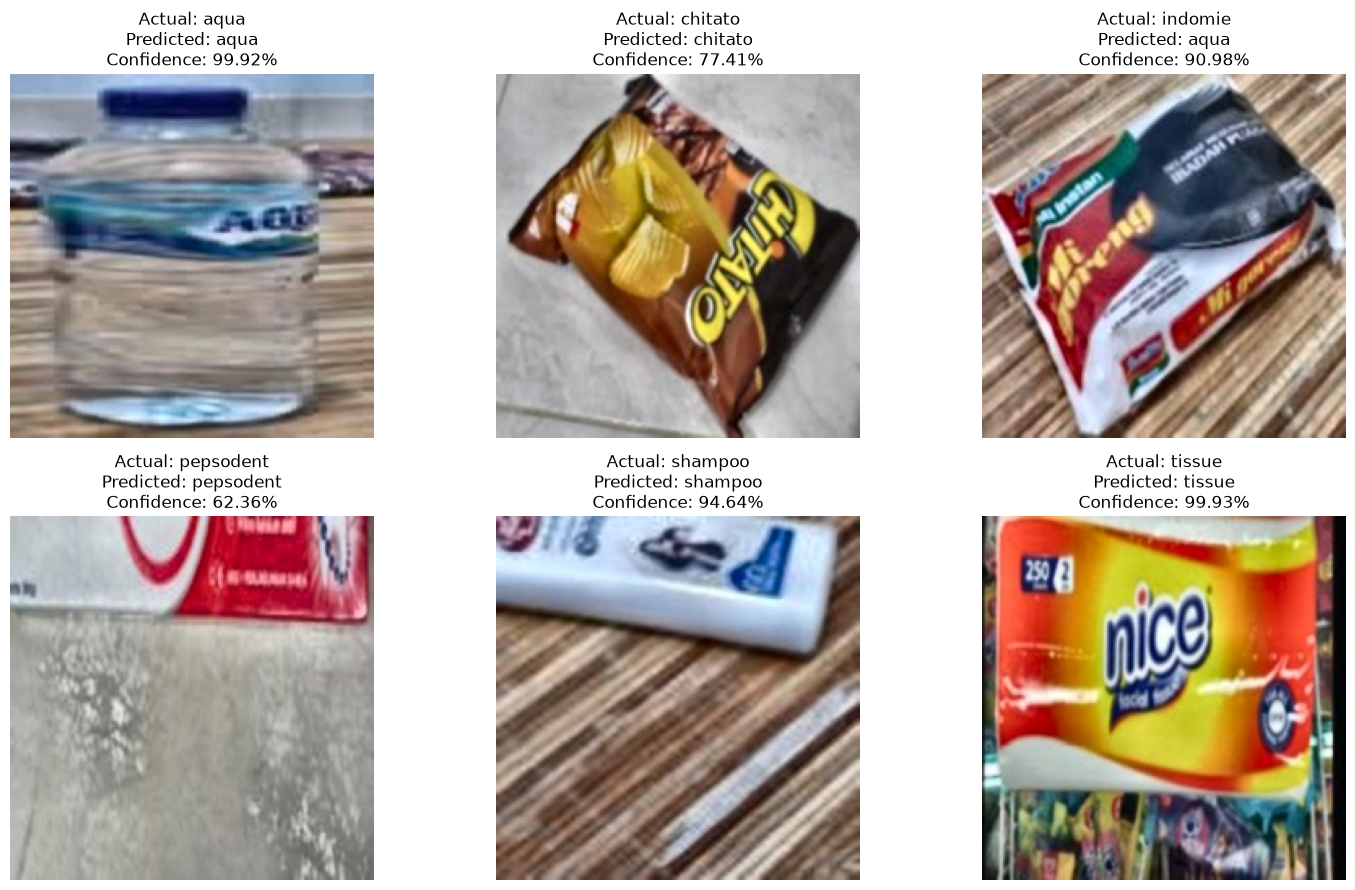

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (actual_product, path), result in zip(
    axes.ravel(),
    test_images.items(),
    results
):

    # Load image
    img = cv2.imread(path)

    # Convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display image
    ax.imshow(img)
    ax.axis("off")

    # Prediction information
    predicted = result["predicted"]
    confidence_value = result["confidence"]

    title = (
        f"Actual: {actual_product}\n"
        f"Predicted: {predicted}\n"
        f"Confidence: {confidence_value:.2f}%"
    )

    ax.set_title(title)

plt.tight_layout()
plt.show()